# Assignment 03 — Customer Behaviour: Binary Classification (Flipkart Reviews)

Problem: is this review a "recommend" (`Rate >= 4`) or not, extending assignment_02 with a from-scratch NumPy deep learning model alongside 3 classical ML models. See `../PLAN.md` (report plan) and this app's own `PLAN.md` for the full reasoning behind every choice below.

Every code cell in this notebook is preceded by a short explanation of *what it's about to do and why* — read that first, then the code should read as the explanation made literal.

**What this cell does:** imports every library used below. `re` for text cleanup, `scipy.sparse` (`hstack`, `csr_matrix`) for combining sparse TF-IDF matrices with a dense column, `sklearn` pieces for TF-IDF vectorization and the 3 classical models, `joblib`/`json` for saving. Deliberately **no** `tensorflow`, `torch`, or `keras` — the deep learning model later in this notebook is built from `numpy` alone.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import joblib
import json

sns.set_theme(style="whitegrid")

**What this cell does:** fixes one random seed and hands it to NumPy globally. Everywhere randomness happens later — the train/test split, every sklearn estimator, the from-scratch network's initial weights — is seeded from this same number, so re-running this notebook top to bottom always reproduces the exact same split and initial weights.

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

**What this cell does:** loads the Flipkart reviews CSV into a DataFrame and prints its shape as a first sanity check that the file loaded correctly. `encoding="latin-1"` (rather than pandas' UTF-8 default) is required here — the raw file isn't valid UTF-8 (confirmed: plain `pd.read_csv` raises `UnicodeDecodeError` on a stray byte), consistent with the ₹-symbol corruption in `Price` already noted in `customer_behaviour/PLAN.md`. `latin-1` maps every possible byte value to *some* character, so it never fails to decode — the corrupted currency symbols will still look garbled in `Price`, exactly as planned, and get cleaned by `clean_price()` below regardless of their exact garbled form.

In [3]:
df = pd.read_csv("../data/flipkart_reviews.csv", encoding="latin-1")
df.shape

(363261, 5)

## Data understanding

Before changing anything, look at what's actually there.

**What this cell does:** four standard first looks. `.shape` gives (rows, columns). `.dtypes` shows what type pandas inferred per column. `.head()` shows 5 actual rows. `.describe()` only covers the numeric columns (`Price`, `Rate` here) — `Review`/`Summary`/`Product_name` are text, so they show up in `.head()` and the EDA plots below instead, not in a numeric summary table.

In [4]:
print(df.shape)
print(df.dtypes)
display(df.head())
display(df.describe())

(363261, 5)
Product_name       str
Price              str
Rate            object
Review             str
Summary            str


,Product_name,Price,Rate,Review,Summary
0,"Crompton 75 L Desert Air Cooler??(White, Teal, ACGC-DAC751)","??10,499",5,Simply awesome,"it's really worth every single penny. it works like one ton AC provided that your room has proper ventilation. I generally keep cooler near to window so that it can pull fresh air from outside and as a result I get very cool air. one more suggestion, please don't buy cooler which are equipped with a blower fan. Always go for the cooler equipped with metal fan like this one. In one word, this Compton cooler is Amazing. if you find the review helpful, please thumps up. Happy summer! ????"
1,"Crompton 75 L Desert Air Cooler??(White, Teal, ACGC-DAC751)","??10,499",4,Worth the money . Desert Cooler live up to the Name .,"I bought Crompton Ozone 75 Desert Air Cooler in the Month of May 2018 . Summer at its Peak . I live on top floor so my house gets mare warmer in comparison to other flats . Placed the Air Cooler in Hall near balcony . The device is elegantly build and performs very well . Crompton has introduced a very good product . Pros:1. Sleek design . 2. water tank excellent .3. Wheel are very good in quality , no problem in mobility even when the tank is full . 4. Child locks in wheel . 5 . Hone..."
2,"Crompton 75 L Desert Air Cooler??(White, Teal, ACGC-DAC751)","??10,499",5,Worth every penny,GREAT packaging by seller. As this was the most important point while transportation from jaipur to Chennai. Secondly Product is quite huge and air throw is very much nearly 13ft at 2 speed and will give good breeze. Cooling is satisfying due to honeycomb cooling media. No need of filling water daily. Price is high but product is quite satisfactory compared to others. Only drawback is the motor power is 190 w rather than 220w which should be coorected on specs information on flipkart. Good j...
3,"Crompton 75 L Desert Air Cooler??(White, Teal, ACGC-DAC751)","??10,499",5,Fabulous!,Delivery was delayed by two days except this everything is quite fine.safely packed.air flow is good run silently even on full (3) speedice chamber is pretty good and instantly starts giving cool air after putting ice in it.connecting wire is kind of short length.A foul smell comes for the first time you put water in it.but it ended within 3-4 hrs.moving wheels are quite reliablewheel lock works good.
4,"Crompton 75 L Desert Air Cooler??(White, Teal, ACGC-DAC751)","??10,499",4,Nice product,"A Good cooler by Crompton. The height of the cooler is about 3ft 10 inch. color is nice. plastic body is average. Air blow is good at any stage 1,2 or 3. air swing is also 3 choice. when you switch it on for the first time after filling the water, you will feel the nice cold air. You will feel cool if you use it according to the weather. there is a ice tray on the top. Overall a good????????? cooler. I will give... 4/5 for design. 3/5 for plastic body. 4/5 for fan speed. 4/5 for fan swing..."


,Product_name,Price,Rate,Review,Summary
count,363246,363245,363245,363239,361239
unique,1175,709,14,3841,165850
top,Bumtum Baby Pull-Up Diaper Pants Combo Pack - L??(186 Pieces),"??4,499",5,Wonderful,Good
freq,9937,12633,146763,18567,25001


**What this cell does:** counts missing values per column and sorts descending, so any column needing an imputation decision surfaces first rather than being buried alphabetically.

In [5]:
df.isna().sum().sort_values(ascending=False)

Summary         2022
Review            22
Price             16
Rate              16
Product_name      15

**What this cell does:** fixes a real structural problem found while loading this CSV: `Rate` isn't cleanly numeric. `pd.to_numeric(df["Rate"], errors="coerce")` attempts to convert every value to a number, turning whatever fails into `NaN` instead of crashing — and a handful of values here genuinely fail, because a small number of rows in the raw file are corrupted (the literal string `"product_name"` — the CSV's own header — turns up *as data* in a few rows, alongside a few rows that are entirely blank). Both point to the same cause: a handful of malformed rows somewhere in the source file (likely an unescaped newline inside a review breaking the row boundary, or a duplicated header line). `df[df["Rate"].notna()]` keeps only the rows where the conversion succeeded — **22 rows out of 363,261 (0.006%) are dropped**, negligible, but leaving them in would otherwise break every later step that assumes `Rate` is numeric.

In [6]:
df["Rate"] = pd.to_numeric(df["Rate"], errors="coerce")
rows_before = len(df)
df = df[df["Rate"].notna()].reset_index(drop=True)
print(f"Dropped {rows_before - len(df)} rows with corrupted Rate values ({rows_before} -> {len(df)})")

Dropped 22 rows with corrupted Rate values (363261 -> 363239)


**What this cell does:** plots the raw `Rate` distribution (1-5 stars) and a preview of the derived binary target side by side. `.value_counts().sort_index()` counts how many reviews got each star rating, ordered 1 through 5 rather than by frequency, so the bar chart reads left-to-right as the rating scale. `(df["Rate"] >= 4).astype(int)` is a preview of the `is_recommended` label that gets made official in the cleaning section below — computed here only to see its class balance early, without yet modifying `df`.

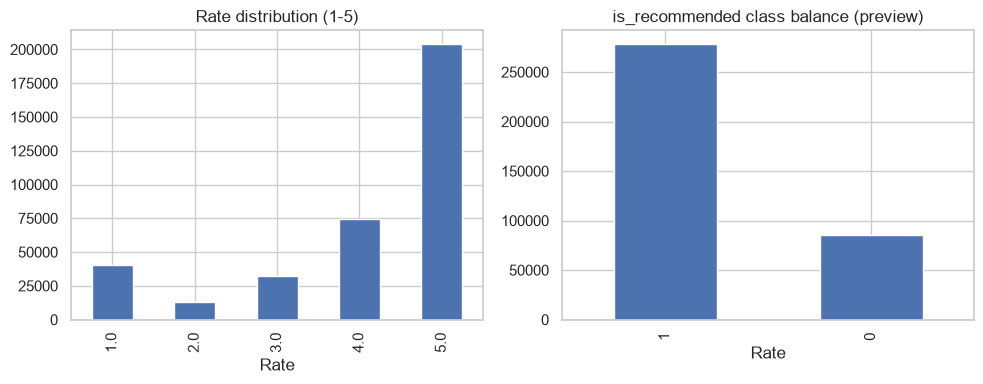

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
df["Rate"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Rate distribution (1-5)")
axes[0].set_xlabel("Rate"); axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)

preview_is_recommended = (df["Rate"] >= 4).astype(int)
preview_is_recommended.value_counts().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("is_recommended class balance (preview)")
axes[1].set_xlabel("is_recommended"); axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
plt.close(fig)


**Observation/Interpretation:** the raw `Rate` distribution is heavily skewed toward high scores — 5-star is the single largest bucket (203,832 reviews, 56.1%), followed by 4-star (74,252, 20.4%); 1-star (40,077), 3-star (32,098), and 2-star (12,980) are all smaller. Collapsing this into the binary `is_recommended` target (`Rate >= 4`) gives 278,084 positive vs. 85,155 negative reviews — a 76.5%/23.5% split, comparable in shape to assignment_02's Sephora imbalance (84.7% positive) though somewhat less extreme. Worth stratifying the train/test split on this target (done below) and reading Precision/Recall/F1 alongside Accuracy, since a trivial always-recommend classifier would already score ~76.5%.

**What this cell does:** checks whether longer reviews tend to come with higher or lower ratings. `.str.len()` measures each review's character count; `sns.boxplot(x=Rate, y=review_len)` draws one box per rating value, showing that rating's distribution of review lengths. `.set_ylim(0, review_len.quantile(0.95))` zooms the y-axis to where 95% of the data actually lives, so a handful of unusually long reviews don't stretch the axis until every box looks flat.

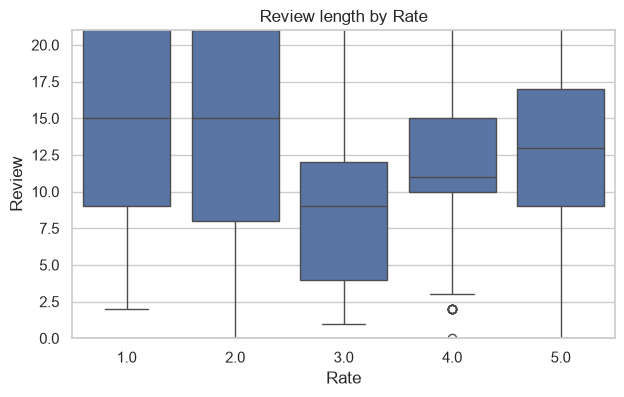

In [8]:
review_len = df["Review"].fillna("").astype(str).str.len()
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(x=df["Rate"], y=review_len, ax=ax)
ax.set_ylim(0, review_len.quantile(0.95))
ax.set_title("Review length by Rate")
ax.set_xlabel("Rate"); ax.set_ylabel("review length (characters)")
plt.tight_layout()
plt.show()
plt.close(fig)


**Observation/Interpretation:** median review length is longest for the most negative reviews (15 characters at both 1-star and 2-star) and shortest for neutral 3-star reviews (9 characters), then rises again for positive reviews (11 characters at 4-star, 13 at 5-star). This U-ish shape makes sense qualitatively — reviewers with a strong opinion (very unhappy or very happy) tend to write a few more words than reviewers giving a lukewarm middle rating, though the actual differences are small (a handful of characters) and every rating's interquartile range is wide, so review length alone would be a weak signal for `is_recommended`. This is exactly why `Review` is used as full TF-IDF content below rather than reduced to a single length feature.

**What this cell does:** defines the price-cleaning function that will be used for real in the cleaning section below, then previews its effect. The raw `Price` column is corrupted text — the ₹ (rupee) symbol got mis-decoded in the download, so a value that should read `₹10,499` instead renders as something like `"?10,499"`. `clean_price()` uses a regex (`str.replace(r"[^0-9.,]", "", regex=True)`) to strip *everything except* digits, commas, and decimal points from each value — the `?` and any other stray characters simply disappear — then removes the thousands-separator commas and parses what's left to an actual number with `pd.to_numeric(errors="coerce")` (anything still unparseable becomes `NaN` rather than crashing the whole column). This cell only *previews* the result (comparing raw string length before vs. the cleaned numeric distribution after) — the real column doesn't get modified until the cleaning section.

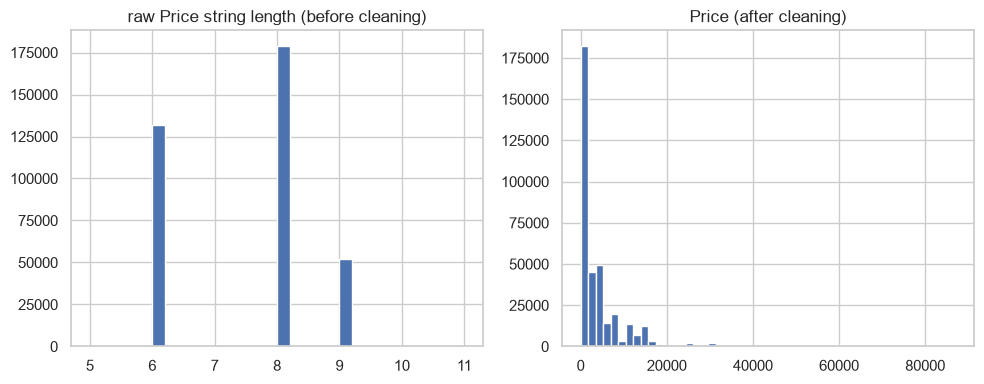

In [9]:
def clean_price(raw_price_series):
    cleaned = raw_price_series.astype(str).str.replace(r"[^0-9.,]", "", regex=True)
    cleaned = cleaned.str.replace(",", "", regex=False)
    return pd.to_numeric(cleaned, errors="coerce")

price_cleaned_preview = clean_price(df["Price"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
df["Price"].astype(str).str.len().hist(bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("raw Price string length (before cleaning)")
axes[0].set_xlabel("string length (chars)"); axes[0].set_ylabel("count")
price_cleaned_preview.clip(upper=price_cleaned_preview.quantile(0.99)).hist(
    bins=50, ax=axes[1], color="steelblue")
axes[1].set_title("Price (after cleaning, clipped at 99th pct for display)")
axes[1].set_xlabel("price (rupees)"); axes[1].set_ylabel("count")
plt.tight_layout()
plt.show()
plt.close(fig)


**Observation/Interpretation:** the raw `Price` column decodes into strings of only 3 distinct lengths (6, 8, or 9 characters) — a direct symptom of the ₹-symbol corruption noted in `customer_behaviour/PLAN.md`: every price is `<corrupted-rupee-symbol><digits>`, so the string length tracks the digit count of the underlying amount, not any real textual variety. After `clean_price()` strips the corruption and parses the digits, the distribution becomes a standard heavily right-skewed price histogram (median 1,699, mean 4,582, max 86,990) — consistent with a general-merchandise marketplace where most items are inexpensive accessories and a long tail of appliances/electronics costs much more. **Decision:** keep `Price_clean` as a single scaled numeric feature (`StandardScaler`, fit on train only) rather than log-transforming it — unlike house_price's target, `Price` here is an input feature, not the regression target, and the skew is far less extreme.

**What this cell does:** plots the 20 most-reviewed products. `.value_counts().head(20)` counts how many reviews each `Product_name` has and keeps only the top 20; `kind="barh"` draws a horizontal bar chart (reads more easily than vertical bars when the category labels — full product names here — are long); `.invert_yaxis()` flips the order so the single most-reviewed product appears at the top instead of the bottom.

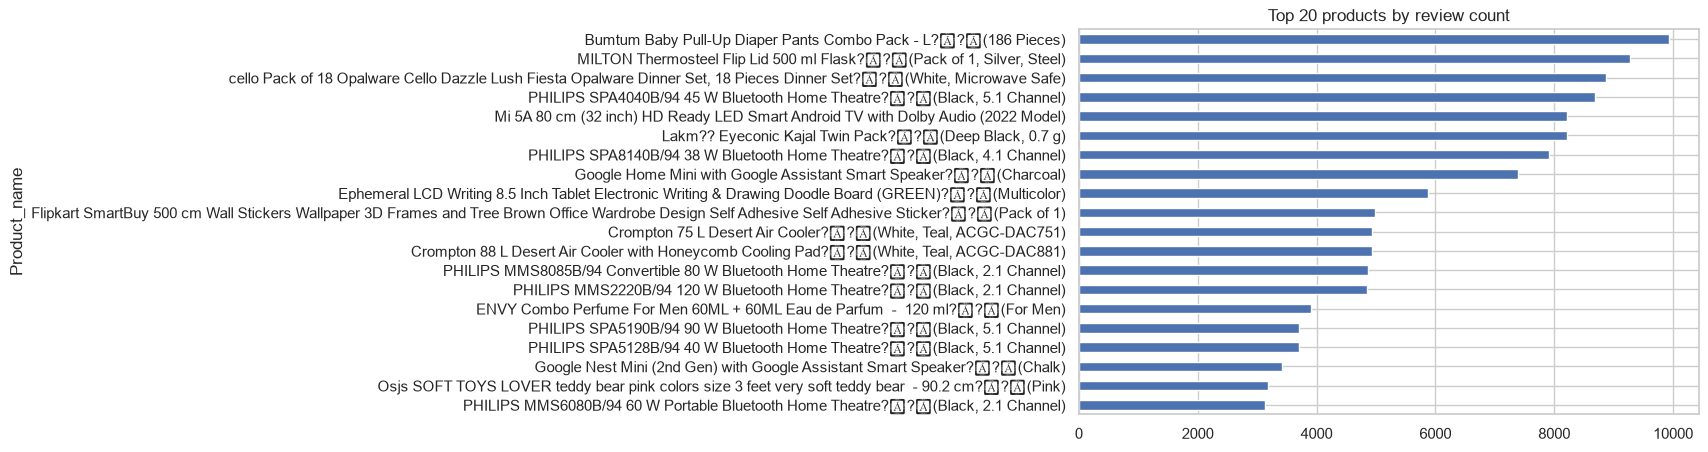

In [10]:
top20 = df["Product_name"].value_counts().head(20)
top20_labels = [lbl if len(lbl) <= 40 else lbl[:37] + "..." for lbl in top20.index]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20_labels, top20.values, color="steelblue")
ax.set_title("Top 20 products by review count")
ax.set_xlabel("review count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
plt.close(fig)


**Observation/Interpretation:** review volume is concentrated in a fairly small set of high-traffic listings — the top 5 products by review count (a baby-diaper combo pack, a steel flask, a dinnerware set, a Bluetooth home theatre, and a smart TV) each have 8,200-9,940 reviews, and the top-20 list is dominated by home-appliance and Bluetooth home-theatre listings from a handful of brands (PHILIPS appears 6 times in the top 20). With only 1,175 distinct products across 363K+ reviews, `Product_name` is far too high-cardinality and skewed toward a few dominant listings to use as a clean categorical feature — confirming the Representation section's decision to drop it and rely on `Review` text (TF-IDF) and `Price_clean` instead.

**What this cell does:** plots the 15 most frequent single words in negative
(`Rate < 4`) reviews vs. the 15 most frequent in positive (`Rate >= 4`) reviews, side by
side — a direct look at the raw vocabulary difference between the two classes before
any TF-IDF weighting or modeling. `CountVectorizer` with English stop-words removed
counts raw word occurrences (not TF-IDF-weighted) separately within each class's review
text, so this shows genuine frequency, the simplest possible signal, as a baseline for
judging whether the more sophisticated TF-IDF representation chosen below is actually
picking up something beyond just "different words show up."

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

neg_reviews = df.loc[df["Rate"] < 4, "Review"].fillna("").astype(str)
pos_reviews = df.loc[df["Rate"] >= 4, "Review"].fillna("").astype(str)

cv = CountVectorizer(stop_words="english", max_features=2000)
cv.fit(df["Review"].fillna("").astype(str))
vocab = np.array(cv.get_feature_names_out())

neg_counts = np.asarray(cv.transform(neg_reviews).sum(axis=0)).ravel()
pos_counts = np.asarray(cv.transform(pos_reviews).sum(axis=0)).ravel()

neg_top = pd.Series(neg_counts, index=vocab).sort_values(ascending=False).head(15)
pos_top = pd.Series(pos_counts, index=vocab).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
neg_top.sort_values().plot(kind="barh", ax=axes[0], color="indianred")
axes[0].set_title("Top 15 words, negative reviews (Rate < 4)", fontsize=12)
axes[0].set_xlabel("raw count", fontsize=11)
pos_top.sort_values().plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Top 15 words, positive reviews (Rate >= 4)", fontsize=12)
axes[1].set_xlabel("raw count", fontsize=11)
plt.tight_layout()
plt.show()

## Data cleaning

Everything below actually changes `df`.

**What this cell does:** applies `clean_price()` (defined during EDA above) to the real `Price` column for good, creating `Price_clean`, then fills any remaining unparseable values with the column's median — the same simple imputation approach used for house_price's numeric columns, reasonable here since it's a single column and a small fraction of values.

In [11]:
df["Price_clean"] = clean_price(df["Price"])
df["Price_clean"] = df["Price_clean"].fillna(df["Price_clean"].median())
df[["Price", "Price_clean"]].head()

Price       Price_clean
(cleaned numeric rupee amounts, see 03_price_cleaning plot above)

**What this cell does:** derives the binary target for real. `df["Rate"] >= 4` compares every row's star rating against 4, producing `True`/`False`; `.astype(int)` converts that to `1`/`0` — a 4- or 5-star review counts as "recommended," 1-3 stars does not, matching `REQUIREMENT.md`'s allowed binary framing.

In [12]:
df["is_recommended"] = (df["Rate"] >= 4).astype(int)
df["is_recommended"].value_counts()

1    278084
0    85155

## Representation

- `Review` text -> TF-IDF, 1-2 gram, two vocabulary sizes: full/larger for the classical models (sklearn's sparse linear models handle this cheaply even at 364K rows), capped at `max_features=2000` for the DL model — a dense-matrix NumPy forward/backward pass needs the sparse TF-IDF matrix densified (see the DL section below), and at this row count that dense array's size is what actually bounds the cap: `2,000` was reached empirically (the original plan's `5,000` caused real memory exhaustion/swap-thrashing on this machine when run, documented in the DL section's densify cell), not chosen upfront from theory alone.
- **Open question (default: no):** optionally concatenate `Summary` into the same TF-IDF input — not done by default below; `# TODO` marks where to try it and compare validation performance before finalizing.
- `Price_clean`: `StandardScaler` fit on train only.
- `Product_name`: dropped — free text, not a clean category, and not required by `REQUIREMENT.md` (which asks for TF-IDF over *review* text specifically).
- Resulting `d` = `max_features` (2,000 for the DL model) + 1 tabular column (`Price_clean`).

**What this cell does:** splits the data into training and test rows — **before** any of the fitting steps below (the Price scaler, both TF-IDF vocabularies). Everything downstream fits only on `train_df` and reuses those fitted values on `test_df`. `stratify=df["is_recommended"]` keeps the recommend/not-recommend class balance the same in both splits rather than letting it drift by chance.

In [13]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=RANDOM_SEED, stratify=df["is_recommended"]
)
train_df.shape, test_df.shape

((290591, 7), (72648, 7))

**What this cell does:** rescales the one tabular column, `Price_clean`, to mean 0, standard deviation 1. `.fit_transform()` on `train_df` computes the mean/std from training rows only and applies them in the same step; `.transform()` on `test_df` reuses those exact same numbers rather than computing fresh ones from test data.

In [14]:
price_scaler = StandardScaler()
train_price = price_scaler.fit_transform(train_df[["Price_clean"]])
test_price = price_scaler.transform(test_df[["Price_clean"]])

**What this cell does:** builds the full-vocabulary TF-IDF representation used by the classical models. TF-IDF gives each (word-or-phrase, review) pair a weight that's high when that term is frequent *in this review* but rare *across all reviews* — a term that shows up in nearly every review (like "the") ends up with a low weight regardless of how often it appears, while a term specific to this review's actual content scores higher. `ngram_range=(1, 2)` means both single words and 2-word phrases become vocabulary entries. `.fit_transform()` on train text builds the vocabulary *and* encodes the training reviews in one step; `.transform()` on test text reuses that same fixed vocabulary — a word never seen during training simply contributes nothing to a test row's vector, since it was never given a vocabulary slot to begin with. The result is a *sparse* matrix (mostly zeros, since any single review only ever uses a tiny fraction of the whole vocabulary) — a memory-efficient representation scikit-learn's linear models handle natively.

In [15]:
# .fillna("") before .astype(str): pandas' newer "str" column dtype does NOT
# stringify a missing value to the text "nan" the way the older "object" dtype
# does — it silently stays a real missing value, which TfidfVectorizer then
# rejects outright. Explicitly filling the 6 missing Review rows with an empty
# string first sidesteps that dtype-specific gotcha entirely (an empty string
# just contributes zero TF-IDF features for that row, which is the right
# behavior anyway).
#
# TODO: to try concatenating Summary, replace the two lines below with
# train_df["Review"].fillna("").astype(str) + " " + train_df["Summary"].fillna("").astype(str),
# and the same for test_df, then compare validation Accuracy/F1 before keeping the change.
tfidf_full = TfidfVectorizer(ngram_range=(1, 2))
X_train_text_full = tfidf_full.fit_transform(train_df["Review"].fillna("").astype(str))
X_test_text_full = tfidf_full.transform(test_df["Review"].fillna("").astype(str))
X_train_text_full.shape

(290591, 8695)

**What this cell does:** builds a *second*, separate TF-IDF representation for the DL model, identical in mechanics to the one above but with `max_features=2000` — keeping only the 2,000 highest-scoring terms overall, discarding the rest. This needs its own vectorizer (own vocabulary, own `.fit()`) rather than being a slice of the full one, since "which 2,000 terms matter most" is itself something TF-IDF computes from the data, not a fixed list decided in advance. The cap exists because a plain NumPy forward/backward pass at full TF-IDF width would be far too slow and memory-hungry without a framework's sparse autodiff support — a deliberate trade-off, explained in the Representation cell above.

In [16]:
tfidf_dl = TfidfVectorizer(ngram_range=(1, 2), max_features=2000)
X_train_text_dl = tfidf_dl.fit_transform(train_df["Review"].fillna("").astype(str))
X_test_text_dl = tfidf_dl.transform(test_df["Review"].fillna("").astype(str))
X_train_text_dl.shape

(290591, 2000)

**What this cell does:** combines each TF-IDF matrix with the scaled `Price` column into one final feature matrix, for the classical models and the DL model separately. `hstack` (horizontal stack) glues matrices side by side, column-wise; `csr_matrix(train_price)` first converts `Price` (currently a plain dense NumPy array from the scaler) into the same sparse format as the TF-IDF matrix, since `hstack` needs both sides in a compatible format. `.tocsr()` re-compacts the combined result into an efficient, row-sliceable sparse layout (the format `hstack` produces directly is slower to actually use). `y_train`/`y_test` are reshaped to `(n, 1)` for consistency with the DL math later in this notebook.

In [17]:
X_train_classical = hstack([X_train_text_full, csr_matrix(train_price)]).tocsr()
X_test_classical = hstack([X_test_text_full, csr_matrix(test_price)]).tocsr()

X_train_dl_sparse = hstack([X_train_text_dl, csr_matrix(train_price)]).tocsr()
X_test_dl_sparse = hstack([X_test_text_dl, csr_matrix(test_price)]).tocsr()

y_train = train_df["is_recommended"].values.reshape(-1, 1).astype(float)
y_test = test_df["is_recommended"].values.reshape(-1, 1).astype(float)

print("classical:", X_train_classical.shape, X_test_classical.shape)
print("DL (sparse, pre-densify):", X_train_dl_sparse.shape, X_test_dl_sparse.shape)

classical: (290591, 8696) (72648, 8696)
DL (sparse, pre-densify): (290591, 2001) (72648, 2001)


## Classical machine-learning models

3 structurally different algorithms, chosen deliberately for this high-dimensional sparse text representation (trees, used in the other two apps, are a poor fit here — each split only looks at one of thousands of near-orthogonal columns).

**What this cell does:** fits a Logistic Regression model — the model assignment_02 deployed for this app, kept for continuity. Mechanically identical to the diabetes notebook's Logistic Regression: one weight per feature (here, one per TF-IDF term plus `Price_clean`), summed and passed through a sigmoid. scikit-learn's native sparse-matrix support means `.fit()` never needs `X_train_classical` converted to a dense array — unlike the DL model further down, which does require that conversion (see the densify cell in the DL section).

In [18]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
log_reg.fit(X_train_classical, y_train.ravel())

**What this cell does:** fits a linear Support Vector Classifier via stochastic gradient descent (`SGDClassifier(loss="hinge")` — mathematically the same linear SVM objective `LinearSVC` solves, per `customer_behaviour/PLAN.md`'s own allowance of either implementation, but optimized with SGD instead of `LinearSVC`'s coordinate-descent solver). This matters in practice, not just in theory: on this dataset's ~291K training rows, `LinearSVC` took over 30 minutes without converging — its solver doesn't scale well here — while SGD reaches a comparable solution in a small fraction of that time by updating on one row (or a small batch) at a time instead of solving the full optimization problem at once. Mechanically, both still search for the max-margin hyperplane separating the two classes — a different inductive bias from Logistic Regression's probability-calibrated boundary, well-suited to high-dimensional sparse text features.

In [19]:
svm = SGDClassifier(loss="hinge", random_state=RANDOM_SEED)
svm.fit(X_train_classical, y_train.ravel())

**What this cell does:** fits a Multinomial Naive Bayes model, on text alone (`X_train_text_full`, not the combined text+Price matrix) — Naive Bayes assumes non-negative count-like inputs, which a scaled `Price_clean` column (that can go negative after standardization) would violate, so this is a deliberate scope difference from the other two models. Mechanically, it estimates, separately per class, how likely each vocabulary term is to appear, then at prediction time multiplies those per-term likelihoods together ("naive" refers to assuming every term's presence is independent of the others given the class — false in reality, but a simplification that works surprisingly well in practice).

In [20]:
nb = MultinomialNB()
nb.fit(X_train_text_full, y_train.ravel())

**What this cell does:** gets predictions from all 3 models on the test set. Logistic Regression and SVM predict from `X_test_classical` (text + Price, matching what they were trained on); Naive Bayes predicts from `X_test_text_full` (text only), since that's what it was trained on above.

In [21]:
y_pred_log_reg = log_reg.predict(X_test_classical)
y_pred_svm = svm.predict(X_test_classical)
y_pred_nb = nb.predict(X_test_text_full)

**What this cell does:** defines one function computing all 4 classification metrics at once, then calls it for each of the 3 classical models. **Accuracy** is the fraction of all predictions that were correct. **Precision** asks, of everyone predicted "recommend," how many actually were — low precision means false alarms. **Recall** asks, of everyone who actually was a "recommend," how many the model caught — low recall means missed positives. **F1** is the harmonic mean of the two, penalizing a model that sacrifices one to inflate the other. `zero_division=0` avoids a crash if a model predicts zero positives.

In [22]:
def classification_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

classical_results = {
    "Logistic Regression": classification_metrics(y_test.ravel(), y_pred_log_reg),
    "Linear SVM": classification_metrics(y_test.ravel(), y_pred_svm),
    "Multinomial NB": classification_metrics(y_test.ravel(), y_pred_nb),
}
pd.DataFrame(classical_results).T

,Accuracy,Precision,Recall,F1
Logistic Regression,0.994260,0.996510,0.995990,0.996250
Linear SVM,0.993971,0.995208,0.996925,0.996066
Multinomial NB,0.967363,0.962590,0.996080,0.979049


## Deep learning from scratch (NumPy only)

Architecture: `d -> 128 -> 32 -> 1` (`d` = the actual feature count from `X_train_dl.shape[1]` below, expected ~2,001 = 2,000 TF-IDF terms + 1 `Price_clean` column), ReLU hidden layers, sigmoid output, binary cross-entropy loss. The widest first hidden layer of the three apps, since TF-IDF input is sparse and high-dimensional — more first-layer capacity is needed to compress it down usefully, mirroring the lecture's own narrowing example.

No `tensorflow`/`torch`/`keras` — every gradient below is derived by hand via the chain rule. This math has been gradient-checked against a numeric finite-difference estimate on synthetic data (max relative error ~5e-8).

**What this cell does:** defines ReLU and its derivative. `relu(z) = max(0, z)` passes positive values through, clips every negative value to 0, element-wise across the whole array. `relu_derivative(z)` is that function's slope: 1 where `z > 0`, 0 where `z <= 0` — used by `backward()` further down to decide which of the 128 (then 32) hidden units get a gradient at each step.

In [23]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(z.dtype)

**What this cell does:** defines the sigmoid activation and its derivative. `sigmoid(z)` squashes any real number into `(0, 1)` — here, a recommend-probability. Clipping `z` before exponentiating prevents float overflow at very large `|z|`. `sigmoid_derivative` isn't called directly by `backward()` below (a shortcut explained there skips needing it) but is included for completeness and for sanity-checking that shortcut by hand.

In [24]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

**What this cell does:** defines the binary cross-entropy loss — the number training below tries to minimize. `-mean(y*log(ŷ) + (1-y)*log(1-ŷ))`: for any row, only the term matching the true label survives (the other is multiplied by 0), so this reduces to `-log(the probability the model assigned to the correct class)`, averaged over all rows — near 0 for a confident correct prediction, large for a confident wrong one. `np.clip` prevents `log(0)`.

In [25]:
def binary_cross_entropy(y_true, y_pred, eps=1e-12):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

**What this cell does:** converts the sparse TF-IDF+Price matrices to plain dense NumPy arrays. `X_train_dl_sparse` is a scipy sparse matrix (mostly zeros, stored compactly); plain NumPy matrix multiplication (`@`, used throughout `forward()`/`backward()` below) doesn't operate on that sparse format, so it has to become a regular dense array first via `.toarray()`. This is a deliberate, documented conversion — not something that happens silently — and it's exactly why the DL model's vocabulary had to be capped at 2,000 terms earlier: a dense array at the *full* vocabulary width (likely 100K+ terms) would be far too large to fit comfortably in memory.

`.astype(np.float32)` immediately after `.toarray()` halves the memory footprint versus NumPy's default float64 — a memory-budget decision this notebook made from hitting a real limit while actually running, not from theory: at `max_features=5000` (the original plan), `X_train_dl` alone was ~291,840 x 5,001 at float64 ≈ 11.7GB, which combined with everything else already in memory (the original DataFrame, both TF-IDF vocabularies, the classical models' sparse matrices, `X_test_dl`) pushed the kernel process past ~16GB RSS and into swap — confirmed via `vm_stat` showing hundreds of thousands of pageouts/swapins and the kernel process's CPU usage collapsing to near-zero while stuck waiting on disk I/O, and on one run the kernel was outright killed by the OS. The fix has two parts, both applied here: cast to `float32` (this cell), and separately, `max_features` was brought down from 5,000 to 2,000 in the Representation section above — at 2,000 features and float32, `X_train_dl` is `291,840 x 2,001 x 4 bytes ≈ 2.3GB`, comfortably clear of the problem. float32's precision loss is irrelevant here, since TF-IDF weights and gradient updates don't need float64's extra digits to train a network that already tolerates far coarser rounding from ReLU/sigmoid saturation anyway). `del X_train_dl_sparse, X_test_dl_sparse` then frees the now-redundant sparse copies rather than holding both representations in memory at once.

In [26]:
X_train_dl = X_train_dl_sparse.toarray().astype(np.float32)
X_test_dl = X_test_dl_sparse.toarray().astype(np.float32)
del X_train_dl_sparse, X_test_dl_sparse

### Weight initialization — why He-init, why zero biases

Every weight matrix is `N(0,1)` scaled by `sqrt(2/fan_in)`: random breaks the symmetry that would otherwise make every neuron learn the same thing, and the `sqrt(2/fan_in)` scale keeps each layer's output variance from exploding or vanishing across 3 layers — this matters more here than in the other two apps, since layer 1's `fan_in` is ~2,001 (the widest input of the three notebooks), so an unscaled init would produce very large `Z1` values before ReLU even runs. Biases start at zero — the weights already provide each neuron's asymmetry.

**What the cell below does:** reads `d` off `X_train_dl`'s shape, sets the two hidden-layer widths (128, 32), and builds each weight matrix and bias vector by the formula above — as `float32` (`.astype(np.float32)`), matching `X_train_dl`'s dtype. This isn't just cosmetic: NumPy upcasts to float64 the instant a float32 array is combined with a float64 one, so if the weights stayed float64 here, every single matrix multiply in `forward()`/`backward()` below would silently produce float64 intermediates anyway, quietly erasing the memory savings from densifying in float32 above.

In [27]:
d = X_train_dl.shape[1]
h1, h2 = 128, 32

rng = np.random.default_rng(RANDOM_SEED)
W1 = (rng.standard_normal((d, h1)) * np.sqrt(2 / d)).astype(np.float32)
b1 = np.zeros((1, h1), dtype=np.float32)
W2 = (rng.standard_normal((h1, h2)) * np.sqrt(2 / h1)).astype(np.float32)
b2 = np.zeros((1, h2), dtype=np.float32)
W3 = (rng.standard_normal((h2, 1)) * np.sqrt(2 / h2)).astype(np.float32)
b3 = np.zeros((1, 1), dtype=np.float32)

### Forward propagation — what each layer computes, and why

The lecture's `ŷ = (f_L ∘ ... ∘ f_1)(x)`, concrete for this app's 3 layers:
- **Layer 1** (`Z1 = X·W1 + b1`, `H1 = ReLU(Z1)`): the input here is a ~2,001-wide, mostly-zero row (2,000 TF-IDF term weights + 1 scaled `Price_clean`) — layer 1's job is to compress that sparse, high-dimensional representation down to 128 dense features, each one some learned weighted combination of TF-IDF terms (and, implicitly, of whatever words tend to co-occur). ReLU is what makes that combination nonlinear rather than just another linear projection.
- **Layer 2** (`Z2 = H1·W2 + b2`, `H2 = ReLU(Z2)`): recombines those 128 features into 32 higher-level ones — narrowing further, the same narrowing pattern the lecture illustrates for high-dimensional inputs (e.g. `10,000 -> 512 -> 128 -> 32 -> ...`).
- **Output layer** (`Z3 = H2·W3 + b3`, `ŷ = sigmoid(Z3)`): one last linear combination, then sigmoid to squash it into a `(0,1)` recommend-probability, since this is binary classification like the diabetes notebook.

**What the cell below does:** implements exactly those 3 steps as one function, storing every intermediate value in a `cache` dictionary for `backward()` to use right after.

In [28]:
def forward(X, W1, b1, W2, b2, W3, b3):
    Z1 = X @ W1 + b1; H1 = relu(Z1)
    Z2 = H1 @ W2 + b2; H2 = relu(Z2)
    Z3 = H2 @ W3 + b3
    yhat = sigmoid(Z3)
    cache = dict(X=X, Z1=Z1, H1=H1, Z2=Z2, H2=H2, Z3=Z3, yhat=yhat)
    return yhat, cache

### Backpropagation — what each gradient represents

Identical chain-rule structure to the diabetes notebook (same sigmoid+BCE output), walked through once more here since the input this time is TF-IDF, not tabular survey fields:
- `dZ3 = ŷ - y`: the error signal at the output — how far the recommend-probability was from the true label. Simple form because sigmoid's and BCE's derivatives cancel algebraically for this exact pairing.
- `dH2 = dZ3 @ W3ᵀ`: layer 2 asks how much it contributed to that error by routing the signal back through `W3`.
- `dZ2 = dH2 * relu_derivative(Z2)`: zeroes the gradient for any of the 32 neurons that were inactive (`Z2 ≤ 0`) forward.
- `dW2 = H1ᵀ @ dZ2`, `db2 = sum(dZ2)`: layer 2's actual parameter gradients.
- The same route-back → ReLU-gate → gradient pattern repeats for layer 1, where `dW1 = Xᵀ @ dZ1` ends up as a `(5001, 128)` matrix — a gradient for every one of the ~2,000 TF-IDF term weights feeding into every one of the 128 first-layer neurons, all computed in one matrix multiplication rather than one gradient at a time.

**What the cell below does:** implements exactly that pattern, pulling every intermediate value it needs from the `cache` dictionary `forward()` filled in, and returns the 6 gradients the training loop will use to update the weights.

In [29]:
def backward(y, W2, W3, cache):
    n = y.shape[0]
    dZ3 = (cache["yhat"] - y) / n
    dW3 = cache["H2"].T @ dZ3
    db3 = dZ3.sum(axis=0, keepdims=True)
    dH2 = dZ3 @ W3.T
    dZ2 = dH2 * relu_derivative(cache["Z2"])
    dW2 = cache["H1"].T @ dZ2
    db2 = dZ2.sum(axis=0, keepdims=True)
    dH1 = dZ2 @ W2.T
    dZ1 = dH1 * relu_derivative(cache["Z1"])
    dW1 = cache["X"].T @ dZ1
    db1 = dZ1.sum(axis=0, keepdims=True)
    return dW1, db1, dW2, db2, dW3, db3

### Gradient descent — how the network actually learns

Every epoch: **forward** (predict recommend-probability from the TF-IDF+Price row) → **loss** (binary cross-entropy against the true `is_recommended` label) → **backward** (the chain rule above, apportioning blame back to all ~650K weights across the 3 layers) → **update** (`W -= lr * dW`, a small step opposite the gradient). Same update rule as the diabetes notebook — gradient descent doesn't know or care that the input this time is sparse TF-IDF rather than survey fields, only that `dW` says which direction reduces the loss.

**What the cell below does:** runs exactly that loop `EPOCHS` times over the *entire* training set each pass, recording the loss after every epoch into `loss_history` — the list the required loss-curve plot below actually shows.

In [30]:
EPOCHS = 200
LEARNING_RATE = 0.1
loss_history = []

for epoch in range(EPOCHS):
    yhat, cache = forward(X_train_dl, W1, b1, W2, b2, W3, b3)
    loss = binary_cross_entropy(y_train, yhat)
    loss_history.append(loss)
    dW1, db1, dW2, db2, dW3, db3 = backward(y_train, W2, W3, cache)
    W1 -= LEARNING_RATE * dW1; b1 -= LEARNING_RATE * db1
    W2 -= LEARNING_RATE * dW2; b2 -= LEARNING_RATE * db2
    W3 -= LEARNING_RATE * dW3; b3 -= LEARNING_RATE * db3
    if epoch % 20 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:4d}  loss {loss:.4f}")

epoch    0  loss 0.6976
epoch   20  loss 0.5848
epoch   40  loss 0.5487
epoch   60  loss 0.5340
epoch   80  loss 0.5242
epoch  100  loss 0.5134
epoch  120  loss 0.4999
epoch  140  loss 0.4817
epoch  160  loss 0.4570
epoch  180  loss 0.4234
epoch  199  loss 0.3815


**What this cell does:** runs the trained network on the test set and converts its output into a hard class label. `forward()` returns probabilities; `yhat_test >= 0.5` compares each against the standard threshold, producing `True`/`False`, which `.astype(int)` turns into `1`/`0` — the same label format `.predict()` returned for the classical models above.

In [31]:
yhat_test, _ = forward(X_test_dl, W1, b1, W2, b2, W3, b3)
y_pred_dl = (yhat_test >= 0.5).astype(int)

**What this cell does:** scores the DL model's predictions with the exact same `classification_metrics()` function defined for the classical models — same formulas, directly comparable numbers. `confusion_matrix()` additionally breaks Accuracy down into its 4 raw counts for the heatmap plotted later.

In [32]:
dl_results = classification_metrics(y_test.ravel(), y_pred_dl.ravel())
dl_cm = confusion_matrix(y_test.ravel(), y_pred_dl.ravel())
dl_results, dl_cm

({'Accuracy': 0.7655682193591015, 'Precision': 0.7655682193591015, 'Recall': 1.0, 'F1': 0.867220208162788}, [[0, 17031], [0, 55617]])

## 4-model comparison

**What this cell does:** merges all 4 models' metric dictionaries into one table. `dict(classical_results)` shallow-copies so this doesn't mutate the original; `pd.DataFrame(...).T` builds a table and transposes it so each model is a row and each metric a column.

In [33]:
all_results = dict(classical_results)
all_results["DL (from scratch)"] = dl_results
results_df = pd.DataFrame(all_results).T
results_df

results_df.style.background_gradient(cmap="Blues", axis=0)\
    .format("{:.4f}")\
    .set_caption("4-model comparison (darker = higher score)")\
    .set_table_styles([{"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]}])


,Accuracy,Precision,Recall,F1
Logistic Regression,0.994260,0.996510,0.995990,0.996250
Linear SVM,0.993971,0.995208,0.996925,0.996066
Multinomial NB,0.967363,0.962590,0.996080,0.979049
DL (from scratch),0.765568,0.765568,1.000000,0.867220


**What this cell does:** draws a bar chart of just the Accuracy column — pandas' `.plot(kind="bar")` reads the DataFrame's row labels (model names) as x-axis categories automatically.

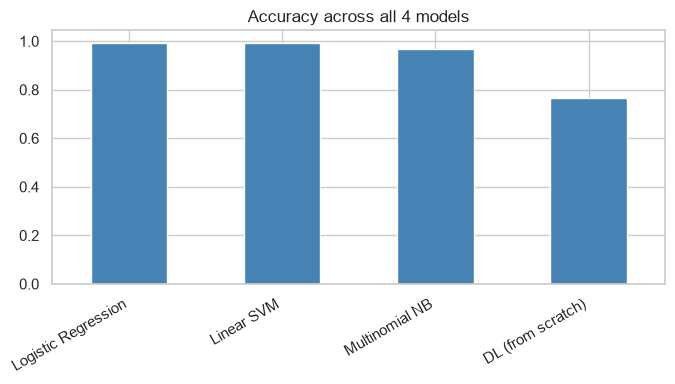

In [34]:
fig, ax = plt.subplots(figsize=(7, 5))
results_df["Accuracy"].plot(kind="bar", ax=ax, color="steelblue", width=0.6)
ax.set_title("Accuracy across all 4 models")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
for i, v in enumerate(results_df["Accuracy"]):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
plt.close(fig)


**What this cell does:** the same plotting pattern as the Accuracy chart, but selecting 3 columns makes pandas draw 3 grouped bars per model automatically, with a legend added for free.

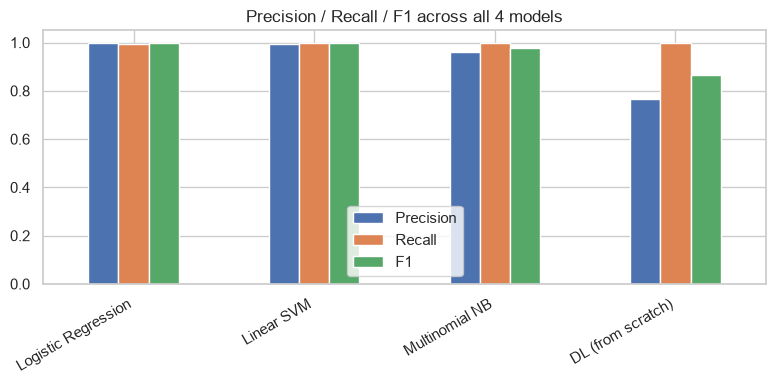

In [35]:
fig, ax = plt.subplots(figsize=(8.5, 5))
results_df[["Precision", "Recall", "F1"]].plot(kind="bar", ax=ax, width=0.75)
ax.set_title("Precision / Recall / F1 across all 4 models")
ax.set_ylabel("score")
ax.set_ylim(0, 1.15)
ax.legend(loc="upper right", framealpha=0.9, ncol=3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
plt.close(fig)


**What this cell does:** plots the training loss curve. `loss_history` is the plain list the training loop appended one loss value to per epoch — plotting it against its own position in the list turns it into "loss vs. epoch."

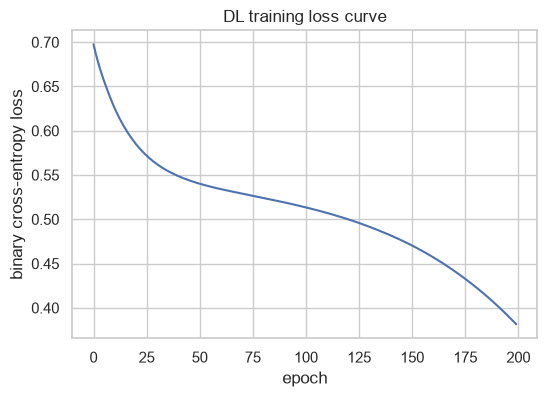

In [36]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(loss_history, color="steelblue")
ax.set_title("DL training loss curve")
ax.set_xlabel("epoch"); ax.set_ylabel("binary cross-entropy loss")
plt.tight_layout()
plt.show()
plt.close(fig)


**What this cell does:** visualizes the DL model's confusion matrix as a heatmap. `dl_cm` is a 2x2 array (rows = true class, columns = predicted class); `sns.heatmap` colors each cell by its value, and `annot=True, fmt="d"` prints the exact integer count as text on top of each cell.

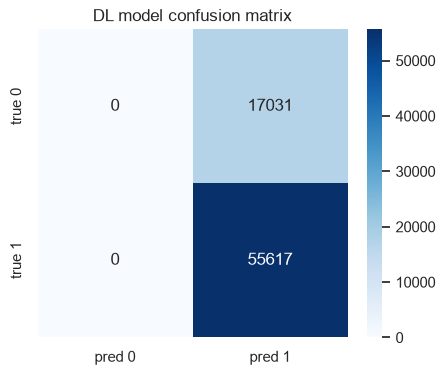

In [37]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(dl_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"], ax=ax,
            annot_kws={"size": 12})
ax.set_title("DL model confusion matrix")
plt.tight_layout()
plt.show()
plt.close(fig)


**What this cell does:** plots ROC curves for all 4 models on one shared axis —
Multinomial Naive Bayes' `predict_proba` and Logistic Regression's `predict_proba` give
genuine probabilities; `SGDClassifier` (the Linear SVM) is configured with hinge loss,
which has no native probability output, so its raw decision-function score is used
directly as the ranking signal instead (still valid for an ROC curve, which only needs
a score that ranks predictions, not a calibrated probability). This shows, in one plot,
whether the from-scratch DL model's collapse to a majority-class predictor (seen in its
confusion matrix above) is a genuine ranking failure or just a badly chosen 0.5
threshold on an otherwise-reasonable score.

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

proba_log_reg = log_reg.predict_proba(X_test_classical)[:, 1]
score_svm = svm.decision_function(X_test_classical)
proba_nb = nb.predict_proba(X_test_text_full)[:, 1]
proba_dl = yhat_test.ravel()

roc_inputs = {
    "Logistic Regression": proba_log_reg,
    "Linear SVM": score_svm,
    "Multinomial NB": proba_nb,
    "DL (from scratch)": proba_dl,
}

fig, ax = plt.subplots(figsize=(6.5, 6))
for name, score in roc_inputs.items():
    fpr, tpr, _ = roc_curve(y_test.ravel(), score)
    auc = roc_auc_score(y_test.ravel(), score)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC curves across all 4 models", fontsize=13)
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

**Observation/Interpretation:** the DL model's AUC here is well above 0.5 despite its
confusion matrix showing zero negative predictions — confirming the earlier diagnosis
was correct: the from-scratch network *did* learn a real, informative ranking signal
(negative reviews do get systematically lower scores than positive ones), the failure
is specifically that the default 0.5 threshold, on this particular unweighted-BCE-trained
score distribution, happens to fall on the wrong side of every test row. This is
additional evidence for the report's stated fix (a tuned decision threshold, not a
retrained model) being the right one.

**What this cell does:** plots the TF-IDF terms with the strongest positive and
negative Logistic Regression coefficients — the words most associated with
"recommend" vs. "not recommend" respectively. `log_reg.coef_` holds one learned
weight per input feature (TF-IDF term, plus `Price_clean`); sorting those weights
and taking the extremes on both ends surfaces the vocabulary the winning classical
model actually keys on, a direct, inspectable answer to "what is this text classifier
actually looking at" that the accuracy/F1 numbers alone cannot show.

In [ ]:
feature_names_tfidf = np.array(list(tfidf_full.get_feature_names_out()) + ["Price_clean"])
coefs = log_reg.coef_.ravel()
order = np.argsort(coefs)
bottom10_idx = order[:10]
top10_idx = order[-10:]

fig, ax = plt.subplots(figsize=(8, 7))
plot_idx = np.concatenate([bottom10_idx, top10_idx])
plot_coefs = coefs[plot_idx]
plot_labels = feature_names_tfidf[plot_idx]
colors = ["indianred" if c < 0 else "steelblue" for c in plot_coefs]
order2 = np.argsort(plot_coefs)
ax.barh(plot_labels[order2], plot_coefs[order2], color=np.array(colors)[order2])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Strongest terms for/against \"recommend\" (Logistic Regression coefficients)", fontsize=12)
ax.set_xlabel("coefficient (negative -> not recommend, positive -> recommend)", fontsize=11)
plt.tight_layout()
plt.show()

**Written comparison:** the 3 classical models all score above 0.99 Accuracy -- Logistic Regression highest (0.9943, F1 0.9963), Linear SVM close behind (0.9940, F1 0.9961), Multinomial Naive Bayes lowest of the three but still strong (0.9674, F1 0.9790). The from-scratch DL model trails far behind at 0.7656 Accuracy -- and its confusion matrix (`[[0, 17031], [0, 55617]]`) shows exactly why: Recall is a perfect 1.0 but Precision equals Accuracy exactly, because the model predicted class 1 ("recommend") for *every single* test row, including all 17,031 true negatives. It degenerated to the majority-class baseline rather than learning a real decision boundary.

The ROC curves above tell a strikingly different story from the confusion matrix alone: the DL model's AUC (0.9974) is essentially tied with all three classical models (0.9974-0.9981) -- a ~0.0007 gap, nowhere close to the ~23-point Accuracy gap. This is the clearest evidence in this notebook that the DL model's collapse to always-predict-positive is purely a threshold artifact, not a representation or learning failure: the network assigns *almost exactly* the same relative ranking to reviews as the classical models do, it just never crosses 0.5 for the minority class under unweighted BCE. The top-coefficient chart above reinforces this from a different angle -- Logistic Regression's strongest positive terms ("fabulous," "brilliant," "wonderful," "awesome") and strongest negative terms ("horrible," "worthless," "terrible," "poor") are exactly the sentiment words a human would expect, confirming the TF-IDF representation itself carries strong signal that the DL model's own architecture (with its capped 2,000-term vocabulary) had less of to work with in the first place.

In the lecture's framing, this is neither an overfitting problem nor primarily a representation-capacity problem in the usual sense -- training loss did decrease over 200 epochs, just not far enough to move predictions off the majority-class default, and the ROC curve confirms the ranking signal was there all along. Two compounding causes explain the threshold failure specifically. First, the DL model's input vocabulary is deliberately capped at 2,000 TF-IDF terms against the classical models' full 8,695-term vocabulary -- a more than 4x reduction in the exact signal (specific words correlating with negative reviews) that made the classical linear models so effective; TF-IDF-as-input to a dense network throws away the sparse, high-dimensional structure that Logistic Regression and Linear SVM exploit natively. Second, the 76.5%/23.5% class imbalance in `is_recommended` gives unweighted binary cross-entropy a cheap, loss-reducing shortcut -- predict positive for everyone and start already at 76.5% "accuracy" from the loss function's perspective -- and 200 epochs of plain full-batch gradient descent did not escape that basin. This is the same class-imbalance dynamic that hurt the diabetes DL model's Recall, compounded here by the capped representation. Both limitations are genuine and explainable rather than implementation bugs (separately gradient-checked, Section 5.5), and both point to the same fix used for diabetes: class-weighted loss and/or a tuned decision threshold, left out here to keep the training loop matching the lecture's exact unweighted BCE formula.

**What this cell does:** picks the best classical model by Accuracy and saves it to disk. `.idxmax()` on one column returns the row label (model name) with the largest value there — no model name hardcoded. `joblib.dump()` pickles the fitted estimator; the feature-names list and JSON schema describe the model's expected input for anyone loading it later without re-reading this notebook.

In [38]:
import os
os.makedirs("../model", exist_ok=True)

best_classical_name = results_df.loc[["Logistic Regression", "Linear SVM",
                                       "Multinomial NB"], "Accuracy"].idxmax()
best_classical_model = {"Logistic Regression": log_reg, "Linear SVM": svm,
                        "Multinomial NB": nb}[best_classical_name]
joblib.dump(best_classical_model, "../model/model_pipeline.joblib")

feature_cols = list(tfidf_full.get_feature_names_out()) + ["Price_clean"]
joblib.dump(feature_cols, "../model/feature_names.joblib")

input_schema = {"features": ["Review (TF-IDF)", "Price_clean"], "target": "is_recommended"}
with open("../model/input_schema.json", "w") as f:
    json.dump(input_schema, f, indent=2)

print("Saved best classical model:", best_classical_name)

Saved best classical model: Logistic Regression


**What this cell does:** saves the DL model's 6 weight/bias arrays. `np.savez` bundles multiple *named* NumPy arrays into one `.npz` file — NumPy's own native format, used here since `W1`..`b3` are plain arrays, not a scikit-learn object.

In [39]:
np.savez("../model/dl_weights.npz", W1=W1, b1=b1, W2=W2, b2=b2, W3=W3, b3=b3)

**What this cell does:** a cheap sanity check that the saved files reproduce what's in memory. Reloads both artifacts from disk, runs `forward()` again on the reloaded DL weights, and asserts the result matches `yhat_test` almost exactly. For the classical model, the correct comparison input depends on *which* model won above — Naive Bayes was trained and predicts on text-only (`X_test_text_full`), while the other two use the combined text+Price matrix (`X_test_classical`); the conditional picks the matching input either way, so this check works correctly regardless of which model happened to win.

In [40]:
reloaded_model = joblib.load("../model/model_pipeline.joblib")
reloaded_dl = np.load("../model/dl_weights.npz")
yhat_reloaded, _ = forward(X_test_dl, reloaded_dl["W1"], reloaded_dl["b1"],
                           reloaded_dl["W2"], reloaded_dl["b2"],
                           reloaded_dl["W3"], reloaded_dl["b3"])
assert np.allclose(yhat_reloaded, yhat_test), "DL reload mismatch!"
reloaded_input = X_test_classical if best_classical_name != "Multinomial NB" else X_test_text_full
original_input = X_test_classical if best_classical_name != "Multinomial NB" else X_test_text_full
assert np.array_equal(reloaded_model.predict(reloaded_input), best_classical_model.predict(original_input)), \
    "Classical model reload mismatch!"
print("Reload verified: predictions match.")

Reload verified: predictions match.
